# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

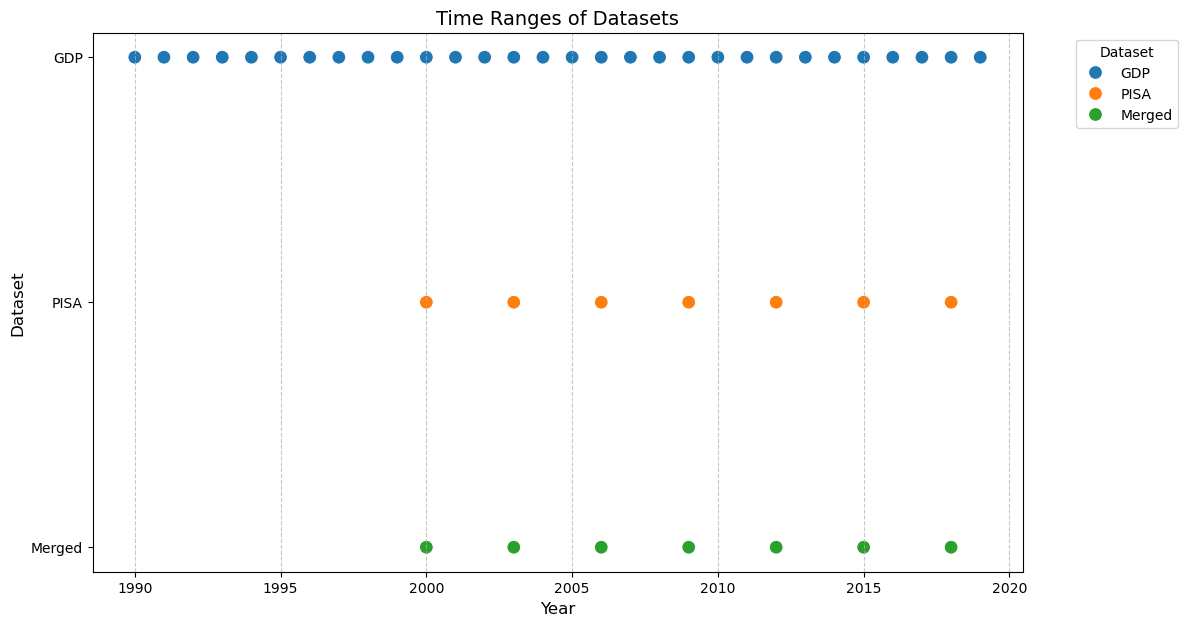

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the datasets
gdp_data = pd.read_csv('data/GDP/GDP.csv')
pisa_data = pd.read_csv('data/PISA/OECD PISA data.csv')
merged_data = pd.read_csv('data/merged.csv')

# Extracting the years
gdp_years = pd.to_numeric(gdp_data.columns[2:], errors='coerce')  # From column 2 onwards are years
pisa_years = pd.to_numeric(pisa_data['TIME'].unique(), errors='coerce')  # Using 'TIME' for years
merged_years = pd.to_numeric(merged_data['Year'].unique(), errors='coerce')  # Using 'Year' for years

# Create a DataFrame for visualization
time_ranges = pd.DataFrame({
    'Year': list(gdp_years) + list(pisa_years) + list(merged_years),
    'Dataset': ['GDP'] * len(gdp_years) + ['PISA'] * len(pisa_years) + ['Merged'] * len(merged_years)
})

# Plot using Seaborn
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=time_ranges,
    x='Year',
    y='Dataset',
    hue='Dataset',
    s=100,
    palette='tab10'
)

# Adding labels and aesthetics
plt.title('Time Ranges of Datasets', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('vis/time_range.svg')
plt.show()


# Load datasets

In [3]:
pisa_data = pd.read_csv("data/PISA/OECD PISA data.csv")
pisa_data.head(10)

,index,LOCATION,INDICATOR,SUBJECT,TIME,Value
0,0,AUS,PISAMATH,BOY,2003,527.000
1,1,AUS,PISAMATH,BOY,2006,527.000
2,2,AUS,PISAMATH,BOY,2009,519.000
3,3,AUS,PISAMATH,BOY,2012,510.115
4,4,AUS,PISAMATH,BOY,2015,497.000
5,5,AUS,PISAMATH,BOY,2018,494.000
6,6,AUS,PISAMATH,GIRL,2003,522.000
7,7,AUS,PISAMATH,GIRL,2006,513.000
8,8,AUS,PISAMATH,GIRL,2009,509.000
9,9,AUS,PISAMATH,GIRL,2012,497.821


In [4]:
pisa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      2087 non-null   int64  
 1   LOCATION   2087 non-null   object 
 2   INDICATOR  2087 non-null   object 
 3   SUBJECT    2087 non-null   object 
 4   TIME       2087 non-null   int64  
 5   Value      2087 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 98.0+ KB


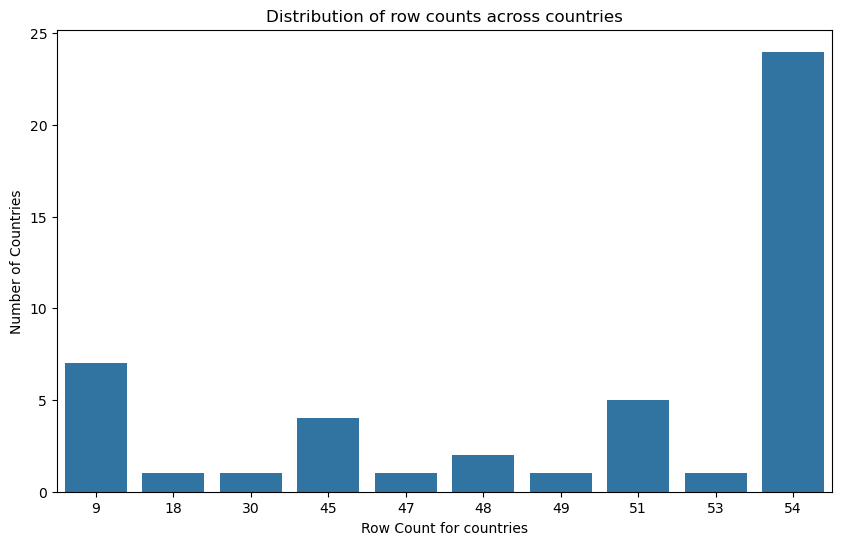

In [5]:


# Convert Series to DataFrame for Seaborn
countries_df = pisa_data["LOCATION"].value_counts().reset_index()
countries_df.columns = ['Country', 'Row_Count']

plt.figure(figsize=(10, 6))
sns.countplot(data=countries_df, x='Row_Count')
plt.xlabel("Row Count for countries")
plt.ylabel("Number of Countries")
plt.title("Distribution of row counts across countries")
plt.show()


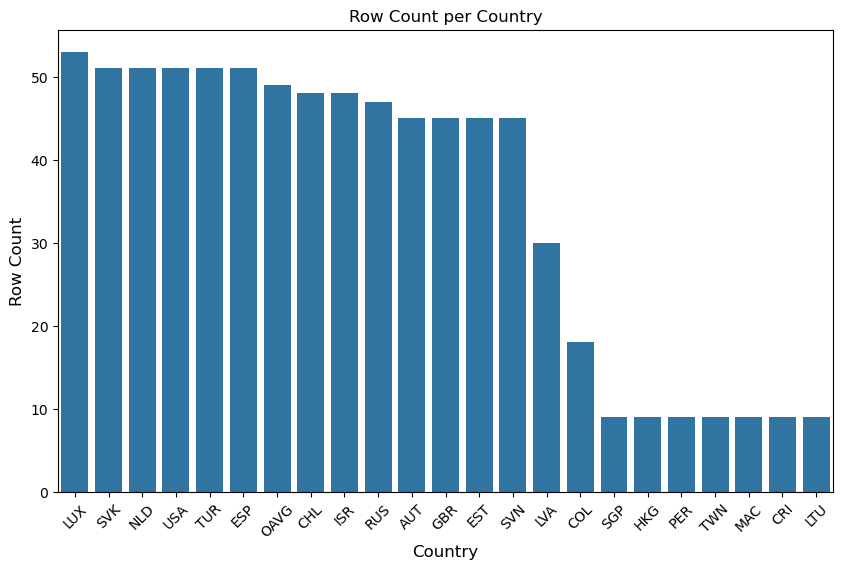

In [6]:

# Example Series
# countries_series = pd.Series({'Country1': 10, 'Country2': 20, 'Country3': 15, ... })


countries_df = countries_df[countries_df["Row_Count"] < countries_df["Row_Count"].max()]

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=countries_df, x='Country', y='Row_Count')
plt.xticks(rotation=45, fontsize=10)  # Adjust tick label font size here
plt.yticks(fontsize=10)  # Adjust y-axis tick label font size
plt.xlabel("Country", fontsize=12)  # Adjust x-axis label font size
plt.ylabel("Row Count", fontsize=12)  # Adjust y-axis label font size
plt.title("Row Count per Country", fontsize=14)  # Adjust title font size
plt.title("Row Count per Country")
plt.show()

In [7]:
gdp_data = pd.read_csv("data/GDP/GDP.csv")
gdp_data.head()

,Country,Country Code,1990,1991,1992,1993,1994,1995,1996,1997,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
0,Aruba,ABW,24101.109430,25870.755940,26533.343900,27430.752400,28656.520210,28648.990020,28499.089430,30215.949230,...,33732.847450,35492.618490,35498.982090,37419.892820,38223.372260,38249.054870,38390.271650,39454.629830,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1637.377987,1626.764793,1806.763930,1874.765634,1897.525938,1886.692977,1896.992520,1934.636754,1955.006208,NaN
2,Angola,AGO,3089.683369,3120.356148,2908.160798,2190.768160,2195.532289,2496.199493,2794.896906,2953.342709,...,6230.297028,6346.395122,6772.528333,6980.423038,7199.245478,7096.600615,6756.935074,6650.584940,6452.355165,NaN
3,Albania,ALB,2549.473022,1909.114038,1823.307673,2057.449657,2289.873135,2665.764906,2980.066288,2717.362124,...,9628.025783,10207.752350,10526.235450,10571.010650,11259.225890,11662.030480,11868.178970,12930.140030,13364.155400,NaN
4,Arab World,ARB,6808.206995,6872.273195,7255.328362,7458.647059,7645.682856,7774.207360,8094.149842,8397.515692,...,14127.778020,14518.827450,15423.465390,15824.780110,16153.244860,16501.792590,16935.383300,17099.889390,17570.137600,NaN


In [8]:
gdp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       260 non-null    object 
 1   Country Code  260 non-null    object 
 2   1990          209 non-null    float64
 3   1991          211 non-null    float64
 4   1992          213 non-null    float64
 5   1993          215 non-null    float64
 6   1994          218 non-null    float64
 7   1995          224 non-null    float64
 8   1996          224 non-null    float64
 9   1997          225 non-null    float64
 10  1998          226 non-null    float64
 11  1999          227 non-null    float64
 12  2000          236 non-null    float64
 13  2001          237 non-null    float64
 14  2002          238 non-null    float64
 15  2003          238 non-null    float64
 16  2004          238 non-null    float64
 17  2005          238 non-null    float64
 18  2006          238 non-null    

In [9]:
# Rename the 'Country ' column to 'Country' to remove the extra space
gdp_data.rename(columns={'Country ': 'Country'}, inplace=True)

# Melt the GDP data to have 'year' and 'GDP' columns for easy merging based on year
gdp_data_melted = pd.melt(gdp_data, id_vars=['Country', 'Country Code'], var_name='year', value_name='GDP')

# Convert the 'year' column in the melted GDP data to int
gdp_data_melted['year'] = gdp_data_melted['year'].astype(int)

gdp_data_melted.head()

,Country,Country Code,year,GDP
0,Aruba,ABW,1990,24101.109430
1,Afghanistan,AFG,1990,NaN
2,Angola,AGO,1990,3089.683369
3,Albania,ALB,1990,2549.473022
4,Arab World,ARB,1990,6808.206995


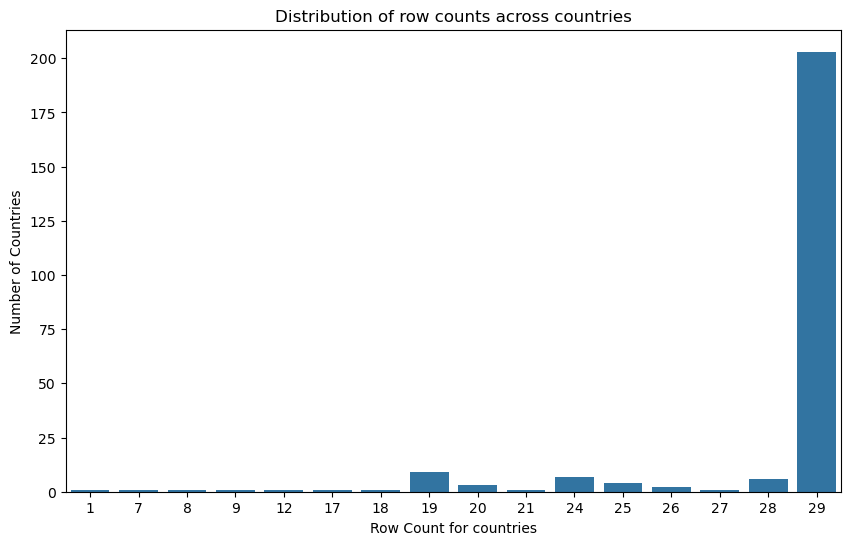

In [10]:
# Convert Series to DataFrame for Seaborn
gdp_countries_df = gdp_data_melted[gdp_data_melted["GDP"].notna()]["Country"].value_counts().reset_index()
gdp_countries_df
gdp_countries_df.columns = ['Country', 'Row_Count']

plt.figure(figsize=(10, 6))
sns.countplot(data=gdp_countries_df, x='Row_Count')
plt.xlabel("Row Count for countries")
plt.ylabel("Number of Countries")
plt.title("Distribution of row counts across countries")
plt.show()

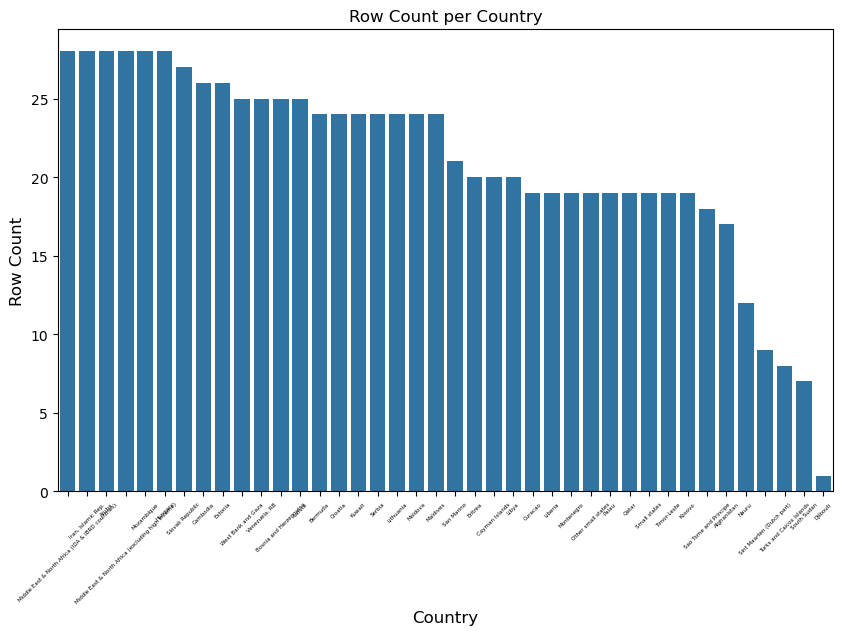

In [11]:
gdp_countries_df = gdp_countries_df[gdp_countries_df["Row_Count"] < gdp_countries_df["Row_Count"].max()]

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=gdp_countries_df, x='Country', y='Row_Count')
plt.xticks(rotation=45, fontsize=4)  # Adjust tick label font size here
plt.yticks(fontsize=10)  # Adjust y-axis tick label font size
plt.xlabel("Country", fontsize=12)  # Adjust x-axis label font size
plt.ylabel("Row Count", fontsize=12)  # Adjust y-axis label font size
plt.title("Row Count per Country", fontsize=14)  # Adjust title font size
plt.title("Row Count per Country")
plt.show()

# Merge datasets

In [12]:
# Perform the merge again on both 'Country Code' and 'year' with matching data types
merged_data = pd.merge(gdp_data_melted, pisa_data, left_on=['Country Code', 'year'], right_on=['LOCATION', 'TIME'], how='inner')

# Display the merged dataset
merged_data

,Country,Country Code,year,GDP,index,LOCATION,INDICATOR,SUBJECT,TIME,Value
0,Australia,AUS,2000,26328.67368,700,AUS,PISAREAD,BOY,2000,513.0
1,Australia,AUS,2000,26328.67368,707,AUS,PISAREAD,GIRL,2000,546.0
2,Australia,AUS,2000,26328.67368,1206,AUS,PISAREAD,TOT,2000,528.0
3,Austria,AUT,2000,29380.06604,714,AUT,PISAREAD,BOY,2000,476.0
4,Austria,AUT,2000,29380.06604,720,AUT,PISAREAD,GIRL,2000,509.0
...,...,...,...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,1103,USA,PISAREAD,GIRL,2018,517.0
2025,United States,USA,2018,62794.58565,1406,USA,PISAREAD,TOT,2018,505.0
2026,United States,USA,2018,62794.58565,1779,USA,PISASCIENCE,BOY,2018,503.0
2027,United States,USA,2018,62794.58565,1784,USA,PISASCIENCE,GIRL,2018,502.0


In [13]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       2029 non-null   object 
 1   Country Code  2029 non-null   object 
 2   year          2029 non-null   int64  
 3   GDP           2029 non-null   float64
 4   index         2029 non-null   int64  
 5   LOCATION      2029 non-null   object 
 6   INDICATOR     2029 non-null   object 
 7   SUBJECT       2029 non-null   object 
 8   TIME          2029 non-null   int64  
 9   Value         2029 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 158.6+ KB


In [14]:
## Number of countries before join in each data set and after join in the merged dataset

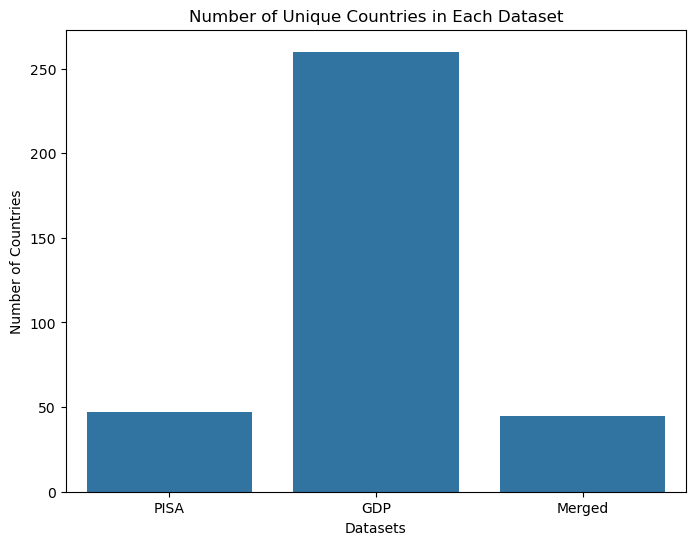

In [15]:
# Example counts
pisa_country_count = pisa_data["LOCATION"].nunique()  # using nunique() is clearer for unique counts
gdp_country_count = gdp_data["Country"].nunique()
merged_country_count = merged_data["Country"].nunique()  # assuming merged_data for the merged dataset

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Datasets': ['PISA', 'GDP', 'Merged'],
    'Number of Countries': [pisa_country_count, gdp_country_count, merged_country_count]
})

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='Datasets', y='Number of Countries')
plt.title("Number of Unique Countries in Each Dataset")
plt.show()

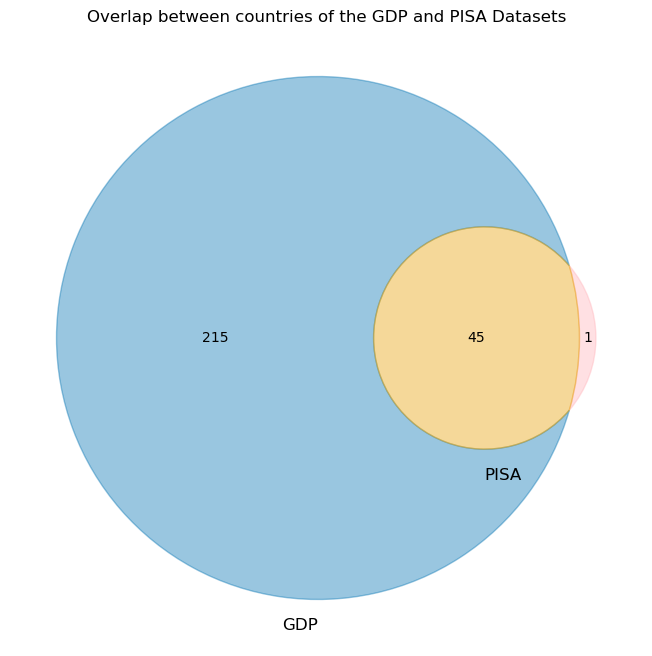

In [16]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Sets of countries in each dataset
gdp_countries = set(gdp_data["Country Code"].unique())
pisa_countries = set(pisa_data["LOCATION"].unique())

# Get the set of countries unique to PISA
unique_to_pisa = pisa_countries - gdp_countries
unique_to_pisa = {"Taiwan"}

# Plot Venn diagram
plt.figure(figsize=(10, 8))
venn = venn2([gdp_countries, pisa_countries], set_labels=('GDP', 'PISA'))
plt.title("Overlap between countries of the GDP and PISA Datasets")

# Clear any existing label in the PISA-only section and set annotation
venn.get_label_by_id('01').set_text('1')  # PISA-only section

venn.get_patch_by_id('10').set_color('#0072B2')  # GDP only
venn.get_patch_by_id('01').set_color('#FFB3BA')  # PISA only
venn.get_patch_by_id('11').set_color('#E69F00')  # Intersection

# Define text for unique PISA countries
unique_pisa_text = '\n'.join(unique_to_pisa)

# Coordinates for the PISA-only section
pisa_only_section = venn.get_label_by_id('01').get_position()
#plt.annotate(unique_pisa_text,
#             xy=pisa_only_section, xycoords='data',  # Arrow start point (PISA-only section)
#             xytext=(0.8, 0.2), textcoords='data',  # Annotation text location to the right
#             ha='center', va='center',
#             bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="#FFB3BA"),
#             arrowprops=dict(arrowstyle="->", color='black'))

plt.savefig('vis/country-overlap.svg')
plt.show()


# Cleanse data

In [17]:
cleansed_data = merged_data.drop(['index', 'LOCATION', 'TIME'], axis=1)
cleansed_data = cleansed_data.rename(columns={"year": "Year", "INDICATOR": "Topic", "SUBJECT": "Gender", "Value": "PISA-Score"})

In [18]:
cleansed_data.to_csv("data/merged.csv")

# INSIGHTS

## Insight 1 - Boys vs. Girls

In [19]:
i1_data = cleansed_data.copy()

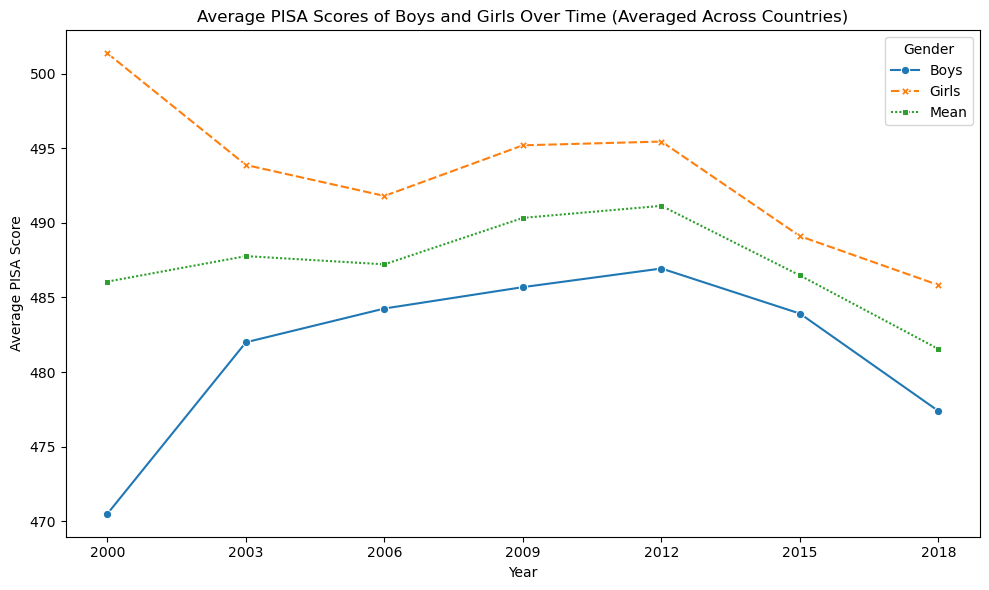

In [20]:
# Calculate the average PISA scores for boys and girls for each year, averaged across all countries
yearly_gender_avg = i1_data.groupby(['Year', 'Gender'])['PISA-Score'].mean().unstack()
yearly_gender_avg.rename(columns={'BOY': 'Boys', 'GIRL': 'Girls', 'TOT': 'Mean'}, inplace=True)
# Plot the average scores of boys and girls for each year
# Using seaborn to plot the average PISA scores of boys and girls for each year
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_gender_avg, markers=True)
plt.xticks(ticks=yearly_gender_avg.index, )  # Rotate if necessary for readability
plt.xlabel('Year')
plt.ylabel('Average PISA Score')
plt.title('Average PISA Scores of Boys and Girls Over Time (Averaged Across Countries)')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('vis/boys_girls.svg')
plt.show()

## Insight 2 - TOP 5 & BOTTOM 5 GDP Countries

In [21]:
i2_data = cleansed_data.copy()
i2_data

,Country,Country Code,Year,GDP,Topic,Gender,PISA-Score
0,Australia,AUS,2000,26328.67368,PISAREAD,BOY,513.0
1,Australia,AUS,2000,26328.67368,PISAREAD,GIRL,546.0
2,Australia,AUS,2000,26328.67368,PISAREAD,TOT,528.0
3,Austria,AUT,2000,29380.06604,PISAREAD,BOY,476.0
4,Austria,AUT,2000,29380.06604,PISAREAD,GIRL,509.0
...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,PISAREAD,GIRL,517.0
2025,United States,USA,2018,62794.58565,PISAREAD,TOT,505.0
2026,United States,USA,2018,62794.58565,PISASCIENCE,BOY,503.0
2027,United States,USA,2018,62794.58565,PISASCIENCE,GIRL,502.0


In [22]:
# Filter data for the years 1990 and 2018
gdp_2000_2018_avg = i2_data[i2_data['Year'].isin([2000, 2018])].groupby(['Country', 'Year'])['GDP'].mean().unstack()

gdp_2000_2018_avg.columns = ['GDP_2000', 'GDP_2018']
gdp_2000_2018_avg


# Identify the top 5 countries by GDP in 2000 and 2018
top_5_2000 = gdp_2000_2018_avg.nlargest(5, 'GDP_2000')
top_5_2018 = gdp_2000_2018_avg.nlargest(5, 'GDP_2018')
bottom_5_2000 = gdp_2000_2018_avg.nsmallest(5, 'GDP_2000')
bottom_5_2018 = gdp_2000_2018_avg.nsmallest(5, 'GDP_2018')

top_5_2000.drop(columns=["GDP_2018"], inplace=True)
top_5_2018.drop(columns=["GDP_2000"], inplace=True)
bottom_5_2000.drop(columns=["GDP_2018"], inplace=True)
bottom_5_2018.drop(columns=["GDP_2000"], inplace=True)


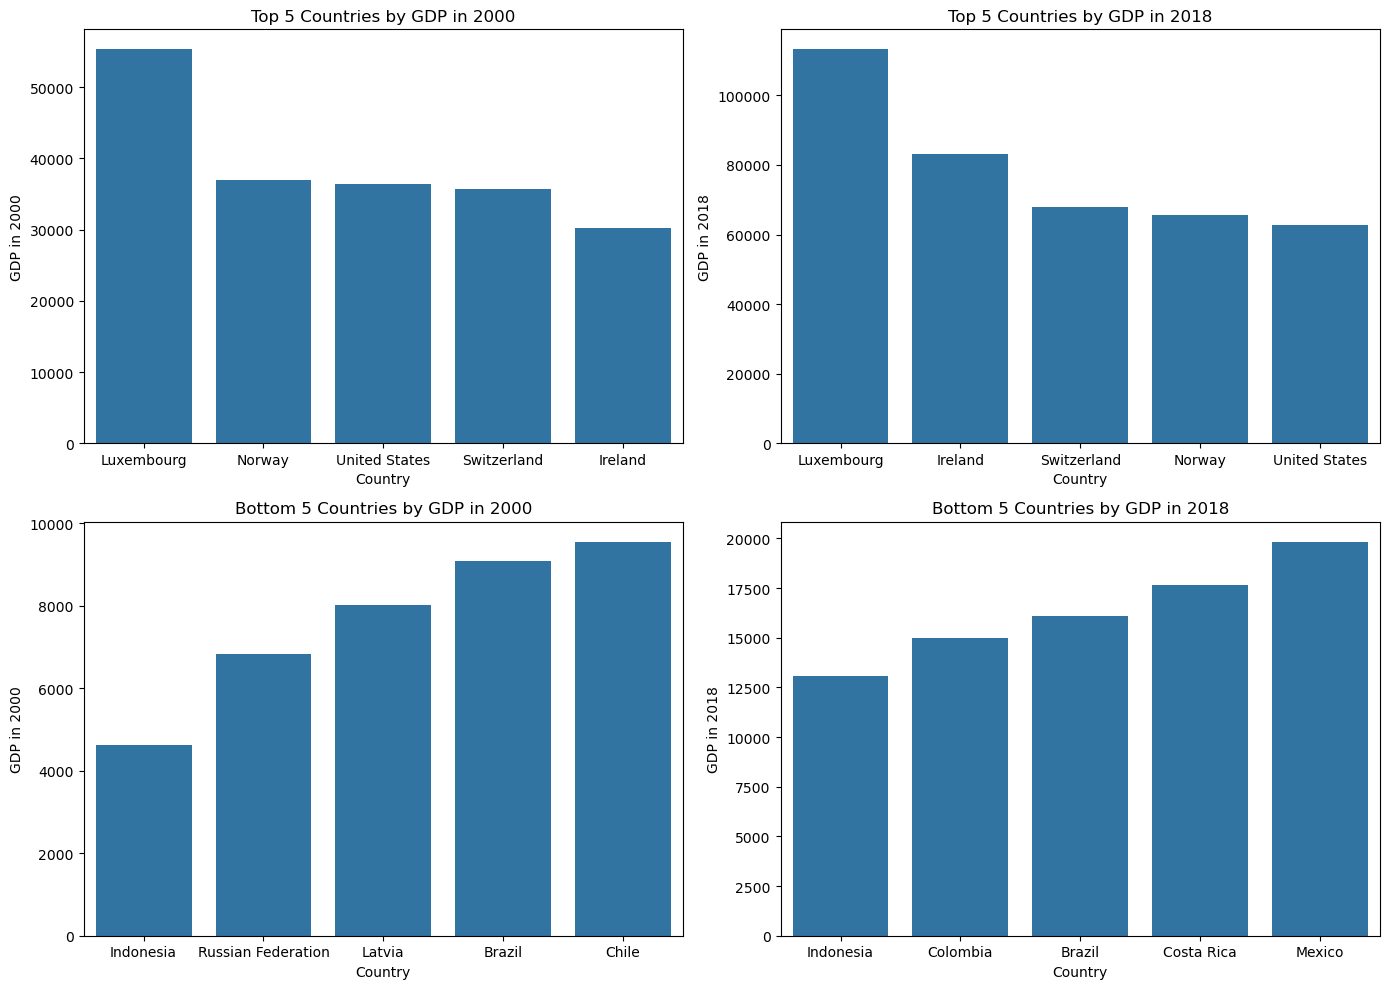

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 2x2 grid for the four bar plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 5 countries by GDP in 2000
sns.barplot(data=top_5_2000.reset_index(), x="Country", y="GDP_2000", ax=axes[0, 0])
axes[0, 0].set_title("Top 5 Countries by GDP in 2000")
axes[0, 0].set_xlabel("Country")
axes[0, 0].set_ylabel("GDP in 2000")

# Top 5 countries by GDP in 2018
sns.barplot(data=top_5_2018.reset_index(), x="Country", y="GDP_2018", ax=axes[0, 1])
axes[0, 1].set_title("Top 5 Countries by GDP in 2018")
axes[0, 1].set_xlabel("Country")
axes[0, 1].set_ylabel("GDP in 2018")

# Bottom 5 countries by GDP in 2000
sns.barplot(data=bottom_5_2000.reset_index(), x="Country", y="GDP_2000", ax=axes[1, 0])
axes[1, 0].set_title("Bottom 5 Countries by GDP in 2000")
axes[1, 0].set_xlabel("Country")
axes[1, 0].set_ylabel("GDP in 2000")

# Bottom 5 countries by GDP in 2018
sns.barplot(data=bottom_5_2018.reset_index(), x="Country", y="GDP_2018", ax=axes[1, 1])
axes[1, 1].set_title("Bottom 5 Countries by GDP in 2018")
axes[1, 1].set_xlabel("Country")
axes[1, 1].set_ylabel("GDP in 2018")

# Adjust layout for better readability
plt.tight_layout()
plt.savefig('vis/top_bottom.svg')
plt.show()


# Insight 3 - GDP vs. PISA score

In [24]:
i3_data = cleansed_data.copy()
i3_data

,Country,Country Code,Year,GDP,Topic,Gender,PISA-Score
0,Australia,AUS,2000,26328.67368,PISAREAD,BOY,513.0
1,Australia,AUS,2000,26328.67368,PISAREAD,GIRL,546.0
2,Australia,AUS,2000,26328.67368,PISAREAD,TOT,528.0
3,Austria,AUT,2000,29380.06604,PISAREAD,BOY,476.0
4,Austria,AUT,2000,29380.06604,PISAREAD,GIRL,509.0
...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,PISAREAD,GIRL,517.0
2025,United States,USA,2018,62794.58565,PISAREAD,TOT,505.0
2026,United States,USA,2018,62794.58565,PISASCIENCE,BOY,503.0
2027,United States,USA,2018,62794.58565,PISASCIENCE,GIRL,502.0


In [25]:
# Group the data by year and calculate the average PISA score and GDP per capita for each country and year
gdp_score_data = i3_data.groupby(['Country', 'Year'])[['GDP', 'PISA-Score']].mean()

# Calculate the correlation between GDP and PISA Score across all countries and years
gdp_pisa_correlation = gdp_score_data['GDP'].corr(gdp_score_data['PISA-Score'])




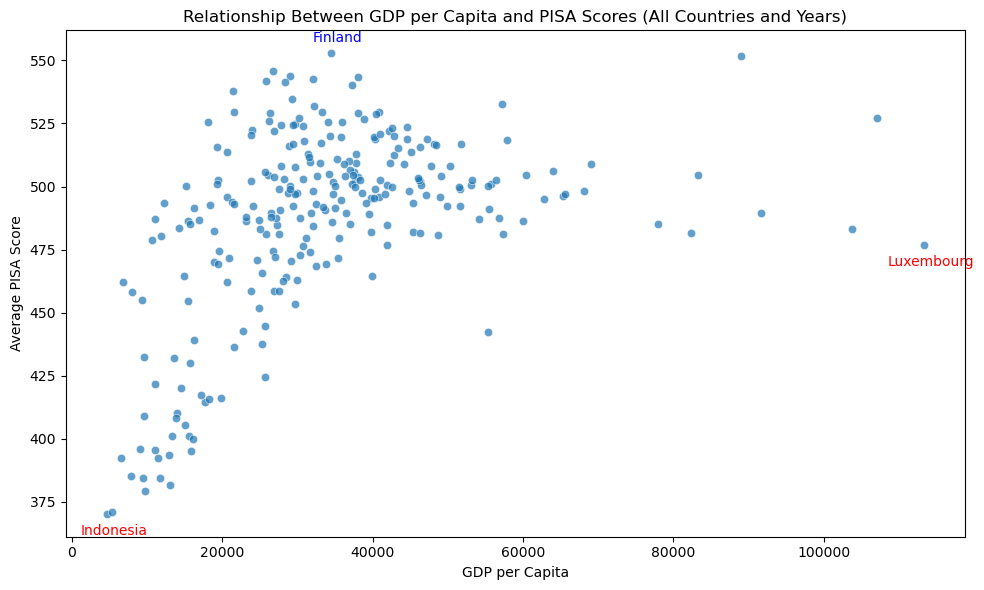

In [26]:
# Identify the country with the highest PISA score and the country with the highest GDP
highest_score = gdp_score_data[gdp_score_data['PISA-Score'] == gdp_score_data['PISA-Score'].max()]
highest_gdp = gdp_score_data[gdp_score_data['GDP'] == gdp_score_data['GDP'].max()]
lowest_gdp = gdp_score_data[gdp_score_data['GDP'] == gdp_score_data['GDP'].min()]

# Plot the scatter plot with annotations
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gdp_score_data, x='GDP', y='PISA-Score', alpha=0.7)

# Annotate the country with the highest PISA score
for idx, row in highest_score.iterrows():
    plt.annotate(row.name[0], (row['GDP'], row['PISA-Score']), 
                 textcoords="offset points", xytext=(5,8), ha='center', color='blue')

# Annotate the country with the highest GDP
for idx, row in highest_gdp.iterrows():
    plt.annotate(row.name[0], (row['GDP'], row['PISA-Score']), 
                 textcoords="offset points", xytext=(5,-15), ha='center', color='red')



# Annotate the country with the highest GDP
for idx, row in lowest_gdp.iterrows():
    plt.annotate(row.name[0], (row['GDP'], row['PISA-Score']), 
                 textcoords="offset points", xytext=(5,-15), ha='center', color='red')

plt.xlabel('GDP per Capita')
plt.ylabel('Average PISA Score')
plt.title('Relationship Between GDP per Capita and PISA Scores (All Countries and Years)')
plt.tight_layout()
plt.savefig('vis/corr_gdp_pisa.svg')
plt.show()


## Insight 4 - GDP-over-the-years vs. Scores-over-the-years

In [27]:
i4_data = cleansed_data.copy()
i4_data

,Country,Country Code,Year,GDP,Topic,Gender,PISA-Score
0,Australia,AUS,2000,26328.67368,PISAREAD,BOY,513.0
1,Australia,AUS,2000,26328.67368,PISAREAD,GIRL,546.0
2,Australia,AUS,2000,26328.67368,PISAREAD,TOT,528.0
3,Austria,AUT,2000,29380.06604,PISAREAD,BOY,476.0
4,Austria,AUT,2000,29380.06604,PISAREAD,GIRL,509.0
...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,PISAREAD,GIRL,517.0
2025,United States,USA,2018,62794.58565,PISAREAD,TOT,505.0
2026,United States,USA,2018,62794.58565,PISASCIENCE,BOY,503.0
2027,United States,USA,2018,62794.58565,PISASCIENCE,GIRL,502.0


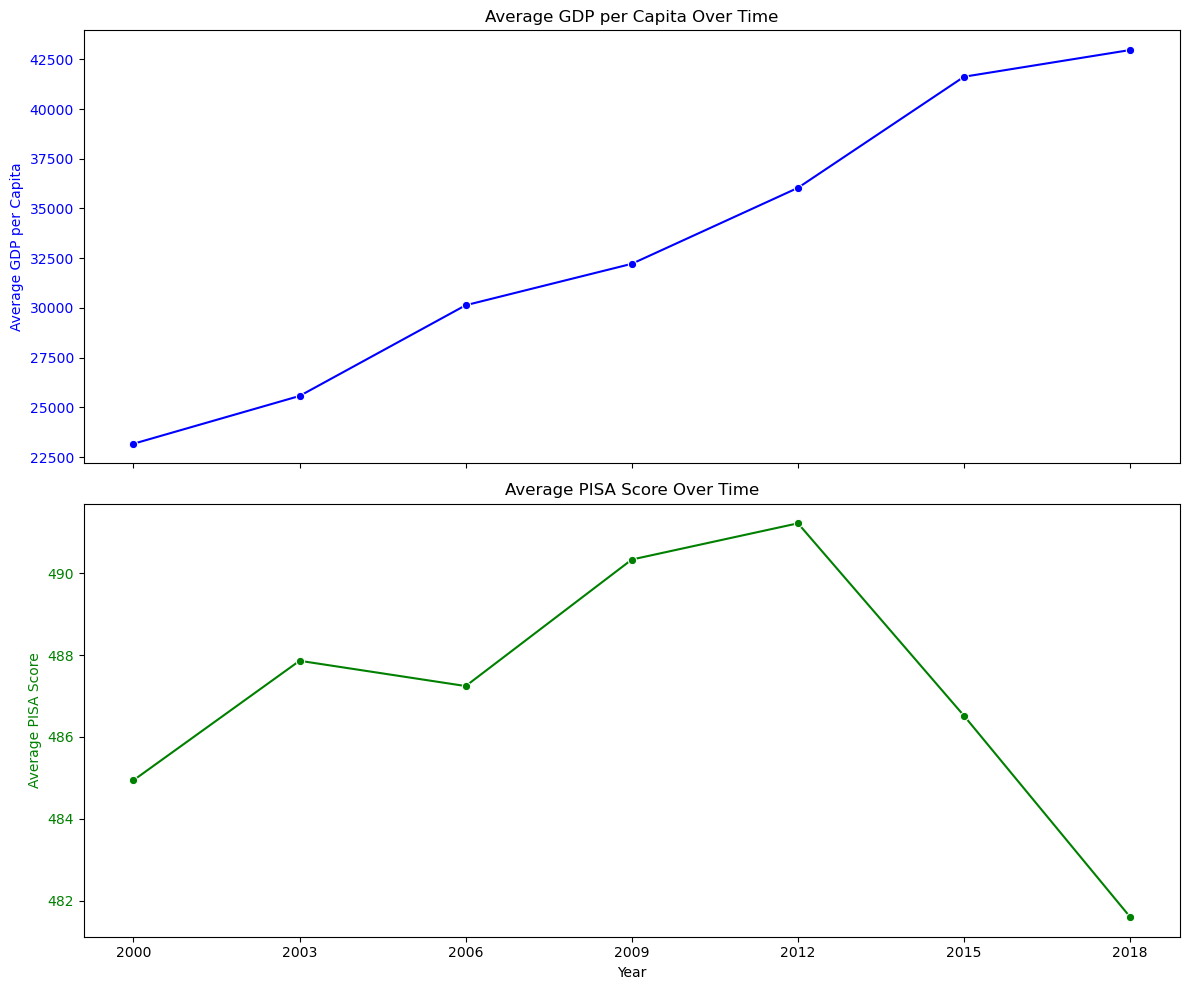

In [28]:
# Using Seaborn to create the plots with limited x-ticks to only the years with data
avg_gdp_score_per_year = i4_data.groupby(['Country', 'Year'])[['GDP', 'PISA-Score']].mean().groupby('Year').mean()[['GDP', 'PISA-Score']]


# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot average GDP in the first subplot using Seaborn
sns.lineplot(data=avg_gdp_score_per_year, x=avg_gdp_score_per_year.index, y='GDP', marker='o', ax=ax1, color='blue')
ax1.set_ylabel('Average GDP per Capita', color='blue')
ax1.set_title('Average GDP per Capita Over Time')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(ticks=avg_gdp_score_per_year.index)


# Plot average PISA score in the second subplot using Seaborn
sns.lineplot(data=avg_gdp_score_per_year, x=avg_gdp_score_per_year.index, y='PISA-Score', marker='o', ax=ax2, color='green')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average PISA Score', color='green')
ax2.set_title('Average PISA Score Over Time')
ax2.tick_params(axis='y', labelcolor='green')



# Layout adjustments for better readability
plt.tight_layout()
plt.savefig('vis/over_time.svg')
plt.show()


## Insight 5 - Average Score in Topics

In [29]:
i5_data = cleansed_data.copy()
i5_data

,Country,Country Code,Year,GDP,Topic,Gender,PISA-Score
0,Australia,AUS,2000,26328.67368,PISAREAD,BOY,513.0
1,Australia,AUS,2000,26328.67368,PISAREAD,GIRL,546.0
2,Australia,AUS,2000,26328.67368,PISAREAD,TOT,528.0
3,Austria,AUT,2000,29380.06604,PISAREAD,BOY,476.0
4,Austria,AUT,2000,29380.06604,PISAREAD,GIRL,509.0
...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,PISAREAD,GIRL,517.0
2025,United States,USA,2018,62794.58565,PISAREAD,TOT,505.0
2026,United States,USA,2018,62794.58565,PISASCIENCE,BOY,503.0
2027,United States,USA,2018,62794.58565,PISASCIENCE,GIRL,502.0


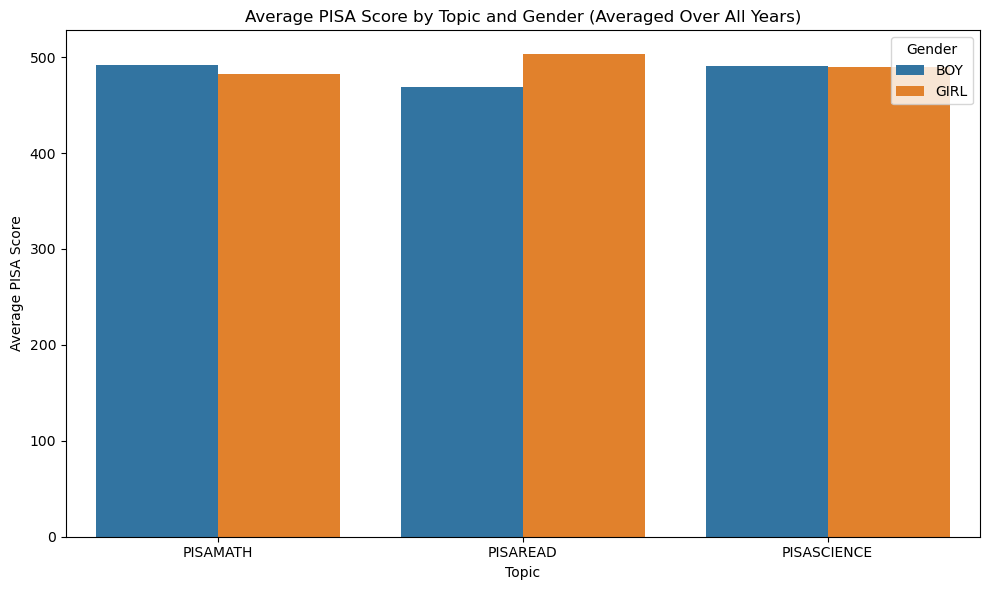

In [30]:

# Filter the data to exclude rows where Gender is 'TOT' and calculate the average score per topic, year, and gender
topic_gender_data = i5_data[(i5_data['Gender'] != 'TOT')].groupby(['Year', 'Gender', 'Topic'])['PISA-Score'].mean().reset_index()



# Calculate the overall average PISA score for each topic and gender across all years, along with the standard deviation
avg_topic_gender = topic_gender_data.groupby(['Topic', 'Gender'])['PISA-Score'].agg(['mean', 'std']).reset_index()

# Plot the overall average score with error bars for standard deviation, grouped by topic and gender
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_topic_gender, x='Topic', y='mean', hue='Gender')


# Customize plot
plt.xlabel('Topic')
plt.ylabel('Average PISA Score')
plt.title('Average PISA Score by Topic and Gender (Averaged Over All Years)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

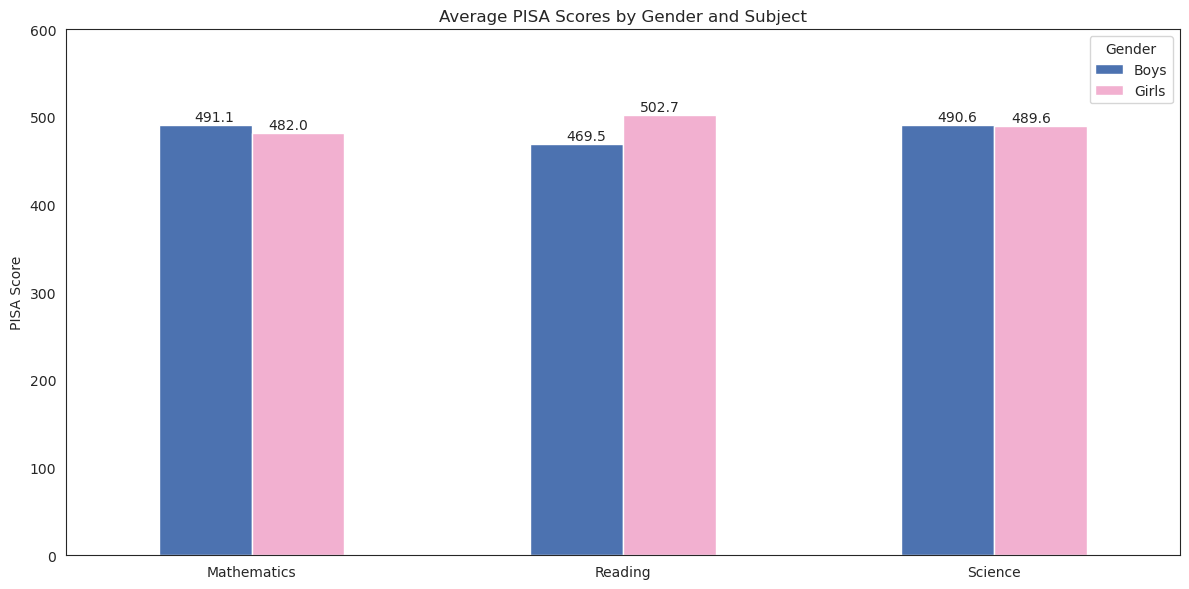

In [31]:
sns.set_style('white')

df = pd.read_csv('data/merged.csv')

# Filter data for boys and girls only

df_gender = df[df['Gender'].isin(['BOY', 'GIRL'])]
# Group by Topic and Gender, then calculate the mean PISA score
gender_avg_scores = df_gender.groupby(['Topic', 'Gender'])['PISA-Score'].mean().unstack()

# Plot the results
plt.figure(figsize=(12, 6))
gender_avg_scores.plot(kind='bar', figsize=(12, 6), color=['#4C72B0', '#F2B0D0'])

plt.title('Average PISA Scores by Gender and Subject')
plt.ylabel('PISA Score')
plt.xlabel('')
plt.xticks([0, 1, 2], ["Mathematics", "Reading", "Science"])
plt.ylim(0, 600)
plt.legend(title='Gender', labels=['Boys', 'Girls'])

# Add value labels to the bars
for i, col in enumerate(gender_avg_scores.columns):
    for j, val in enumerate(gender_avg_scores[col]):
        plt.text(j + (i - 0.5) * 0.2, val + 1, f'{val:.1f}', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('vis/boys_girls.svg')
plt.show()



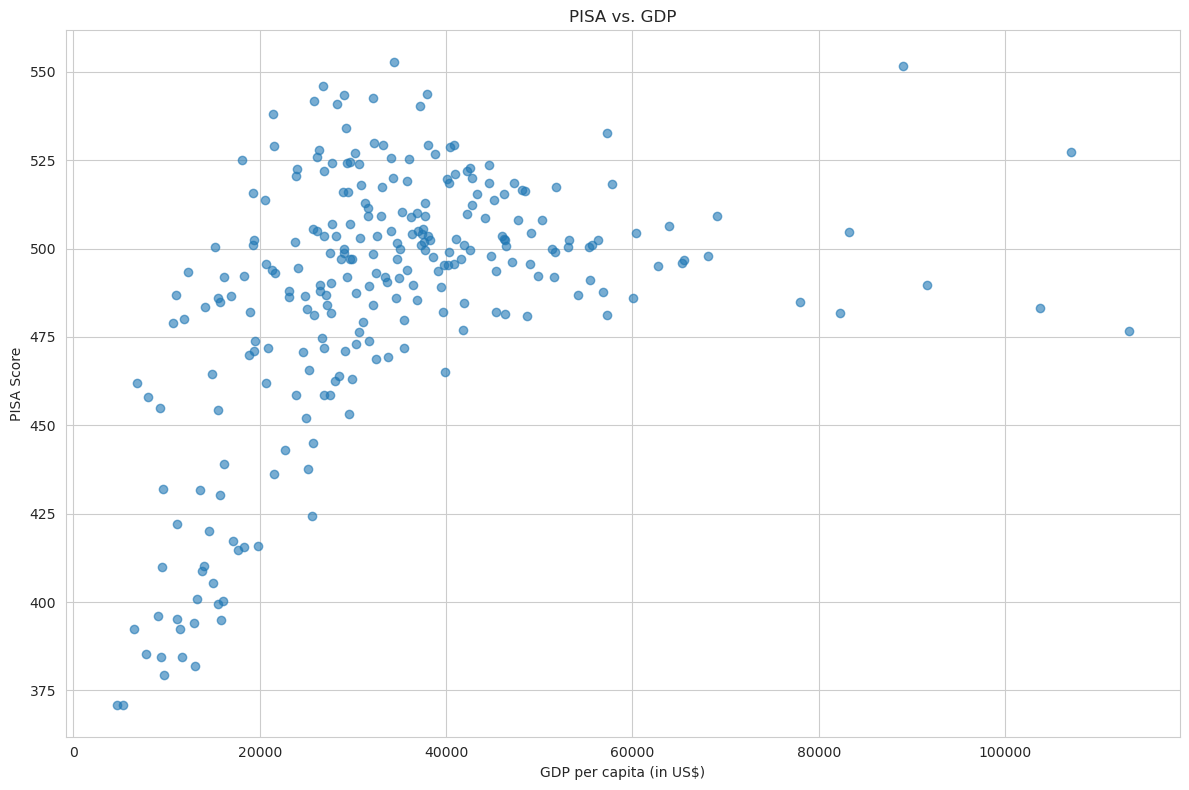

In [32]:
sns.set_style('whitegrid')

# Calculate average PISA score and GDP for each country and year
df_avg = df[df['Gender'] == 'TOT'].groupby(['Country', 'Year']).agg({
    'PISA-Score': 'mean',
    'GDP': 'first'  # GDP is same for all entries in same year/country
}).reset_index()



# Create simple scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df_avg['GDP'], df_avg['PISA-Score'], alpha=0.6)

plt.title('PISA vs. GDP')
plt.xlabel('GDP per capita (in US$)')
plt.ylabel('PISA Score')

plt.tight_layout()
plt.savefig('vis/corr_gdp_pisa.svg')
plt.show()

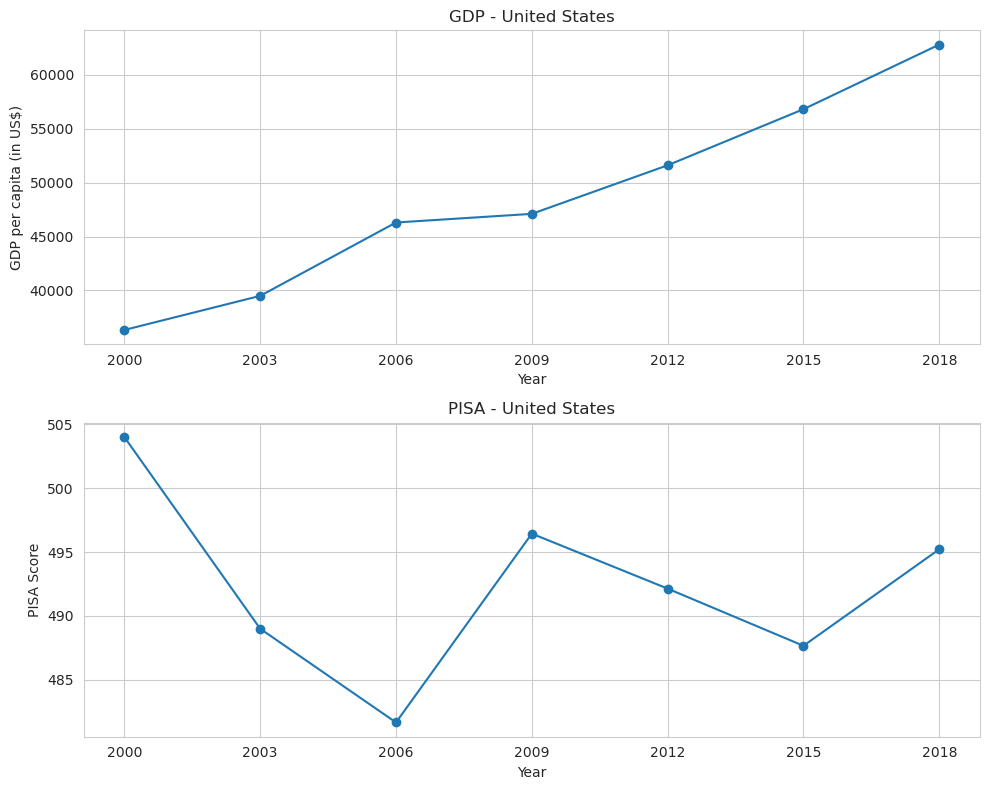

In [33]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('data/merged.csv')

# Filter data for Austria and Brazil
austria_data = data[data['Country'] == 'United States']

# Group by year and calculate average PISA score for each year
austria_avg_pisa = austria_data.groupby('Year')['PISA-Score'].mean()
austria_avg_pisa = austria_data.groupby(['Year', ])['PISA-Score'].mean()

# Extract GDP data for Austria and Brazil
austria_gdp = austria_data.groupby('Year')['GDP'].mean()

years_with_data = sorted(austria_data['Year'].unique())


# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# First subplot: GDP over years
axes[0].plot(austria_gdp.index, austria_gdp.values, label='United States', marker='o')
axes[0].set_title('GDP - United States')
axes[0].set_xlabel('Year')
axes[0].set_xticks(years_with_data)
axes[0].set_ylabel('GDP per capita (in US$)')


# Second subplot: Average PISA Score over years
axes[1].plot(austria_avg_pisa.index, austria_avg_pisa.values, label='United States', marker='o')
axes[1].set_title('PISA - United States')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('PISA Score')
axes[1].set_xticks(years_with_data)


# Adjust layout and show plot
plt.tight_layout()
plt.savefig('vis/time_range.svg')
plt.show()

## Insight 6 - Best/Worst in each topic

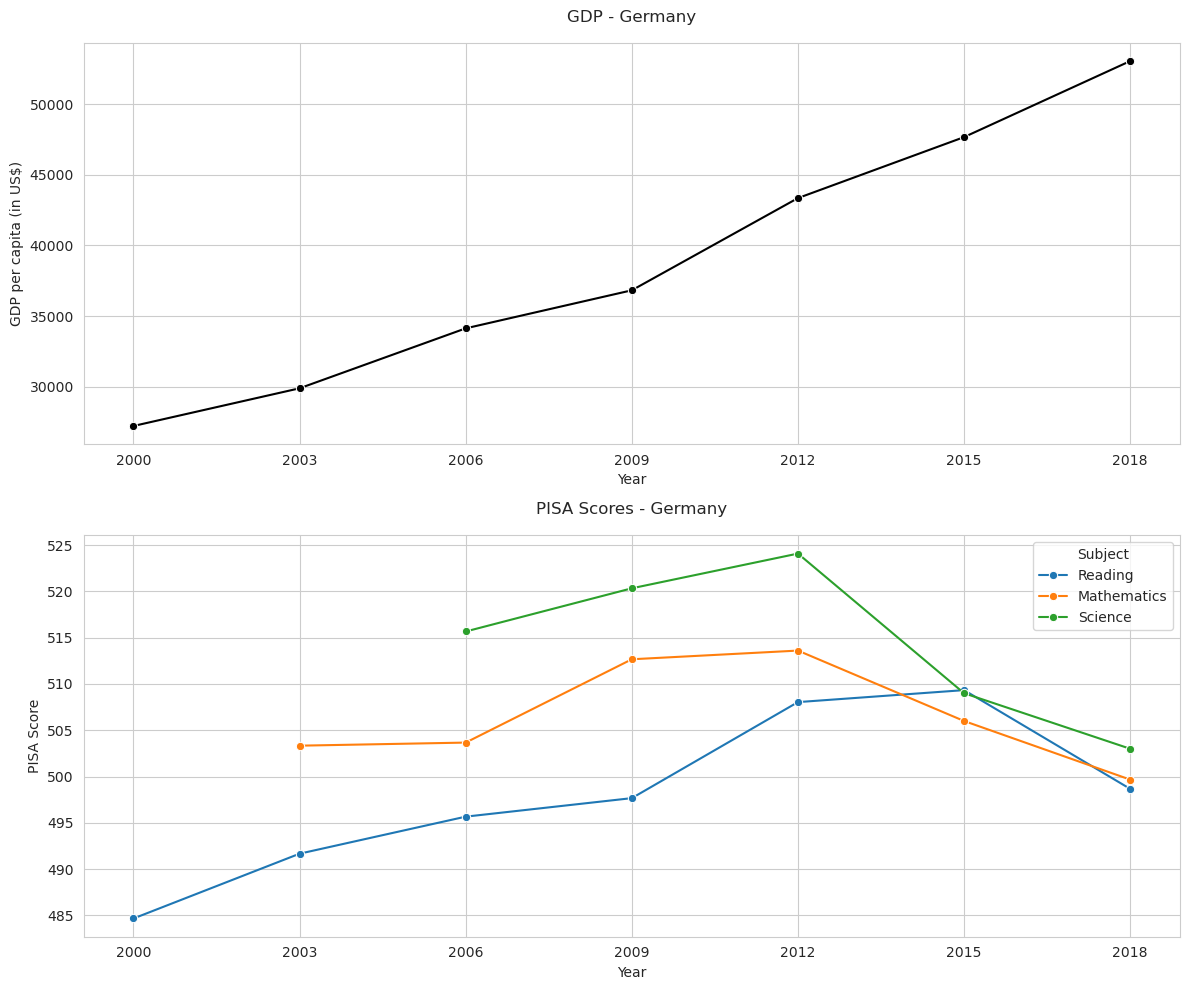

In [34]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('data/merged.csv')

# Filter data for the United States
us_data = data[data['Country'] == 'Germany']

# Set the style
sns.set_style("whitegrid")

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# First subplot: GDP over years using seaborn
sns.lineplot(data=us_data, x='Year', y='GDP', marker='o', color='black', ax=ax1, errorbar=None)
ax1.set_title('GDP - Germany', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per capita (in US$)')
ax1.set_xticks(years_with_data)

# Second subplot: PISA Scores by Topic over years using seaborn
sns.lineplot(data=us_data, x='Year', y='PISA-Score', hue='Topic', marker='o', ax=ax2, errorbar=None)
ax2.set_title('PISA Scores - Germany', pad=15)
ax2.set_xlabel('Year')
ax2.set_ylabel('PISA Score')
ax2.set_xticks(years_with_data)
handles, _ = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Reading', 'Mathematics', 'Science'], title='Subject')


# Adjust layout
plt.tight_layout()
plt.savefig('vis/time_range2.svg')

plt.show()

In [35]:
i6_data = cleansed_data.copy()
i6_data

,Country,Country Code,Year,GDP,Topic,Gender,PISA-Score
0,Australia,AUS,2000,26328.67368,PISAREAD,BOY,513.0
1,Australia,AUS,2000,26328.67368,PISAREAD,GIRL,546.0
2,Australia,AUS,2000,26328.67368,PISAREAD,TOT,528.0
3,Austria,AUT,2000,29380.06604,PISAREAD,BOY,476.0
4,Austria,AUT,2000,29380.06604,PISAREAD,GIRL,509.0
...,...,...,...,...,...,...,...
2024,United States,USA,2018,62794.58565,PISAREAD,GIRL,517.0
2025,United States,USA,2018,62794.58565,PISAREAD,TOT,505.0
2026,United States,USA,2018,62794.58565,PISASCIENCE,BOY,503.0
2027,United States,USA,2018,62794.58565,PISASCIENCE,GIRL,502.0


# Model

## Regresion

In [36]:
model_data = gdp_score_data.reset_index()
model_data

,Country,Year,GDP,PISA-Score
0,Australia,2000,26328.67368,529.000000
1,Australia,2003,29693.90591,524.833333
2,Australia,2006,34306.65231,520.111111
3,Australia,2009,40300.30823,518.666667
4,Australia,2012,42826.78958,512.491111
...,...,...,...,...
257,United States,2006,46298.73144,481.666667
258,United States,2009,47099.98047,496.444444
259,United States,2012,51603.49726,492.140333
260,United States,2015,56803.47243,487.666667


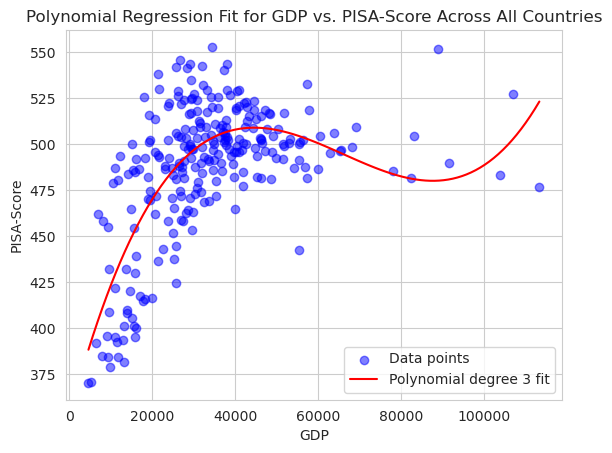

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Extract GDP and PISA-Score columns
X = model_data['GDP'].values.reshape(-1, 1)
y = model_data['PISA-Score'].values

# Set the polynomial degree
degree = 3  # Using a higher degree for potentially complex relationships
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Train a linear regression model on the polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# Generate predictions for plotting the curve
X_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_fit_poly = poly_features.transform(X_fit)
y_pred = model.predict(X_fit_poly)

       

# Plot the original data points and the fitted polynomial curve
plt.scatter(X, y, color='blue', label='Data points', alpha=0.5)
plt.plot(X_fit, y_pred, color='red', label=f'Polynomial degree {degree} fit')
plt.xlabel("GDP")
plt.ylabel("PISA-Score")
plt.legend()
plt.title("Polynomial Regression Fit for GDP vs. PISA-Score Across All Countries")
plt.show()


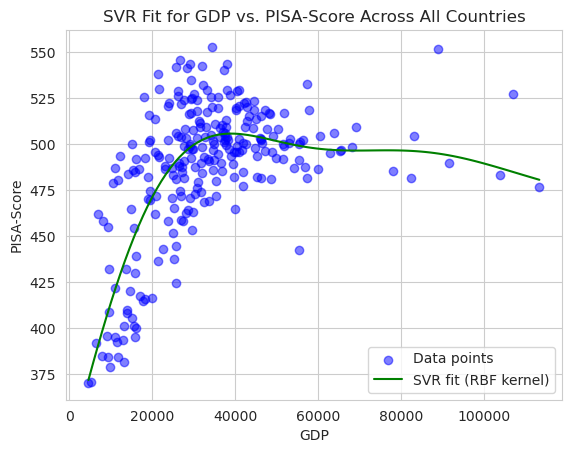

In [38]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Standardize the data for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Train an SVR model on the standardized data
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_scaled, y_scaled)

# Generate predictions for plotting
X_fit_scaled = scaler_X.transform(X_fit)
y_fit_scaled = svr_model.predict(X_fit_scaled)
y_fit = scaler_y.inverse_transform(y_fit_scaled.reshape(-1, 1)).flatten()

# Plot the original data points and the SVR regression curve
plt.scatter(X, y, color='blue', label='Data points', alpha=0.5)
plt.plot(X_fit, y_fit, color='green', label='SVR fit (RBF kernel)')
plt.xlabel("GDP")
plt.ylabel("PISA-Score")
plt.legend()
plt.title("SVR Fit for GDP vs. PISA-Score Across All Countries")
plt.show()


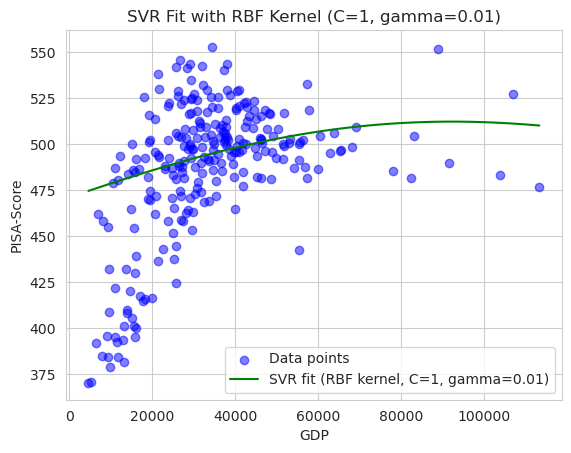

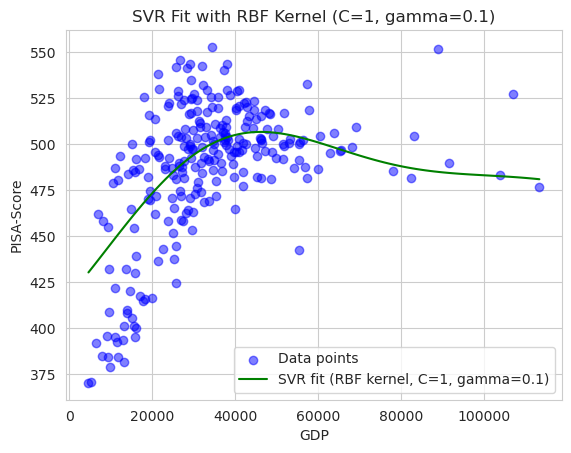

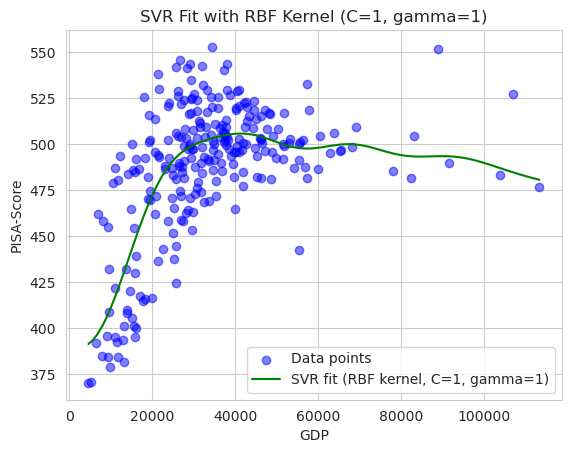

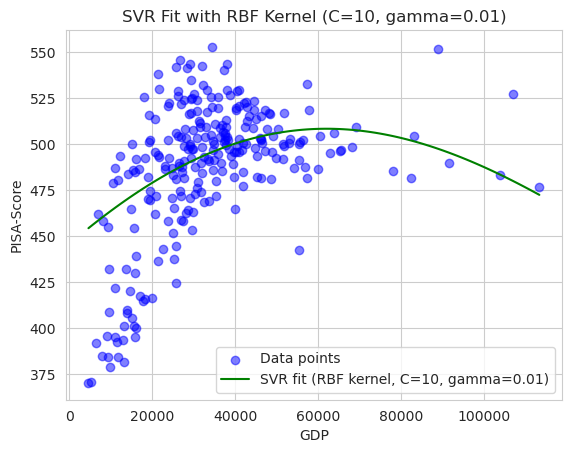

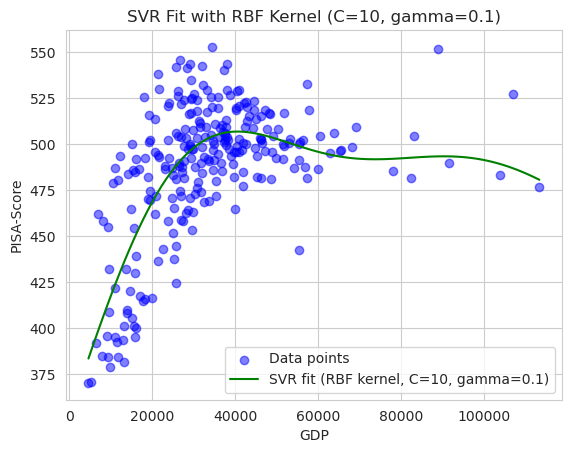

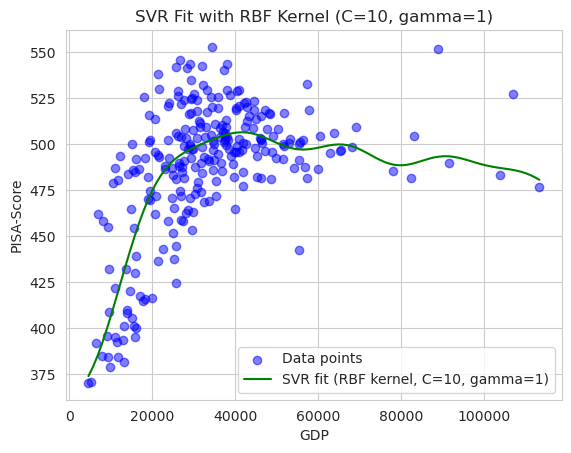

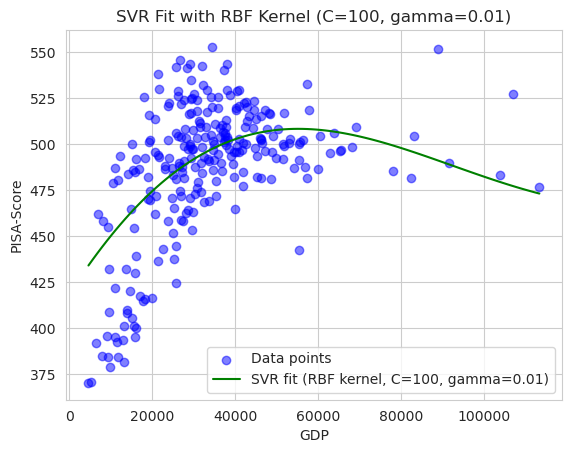

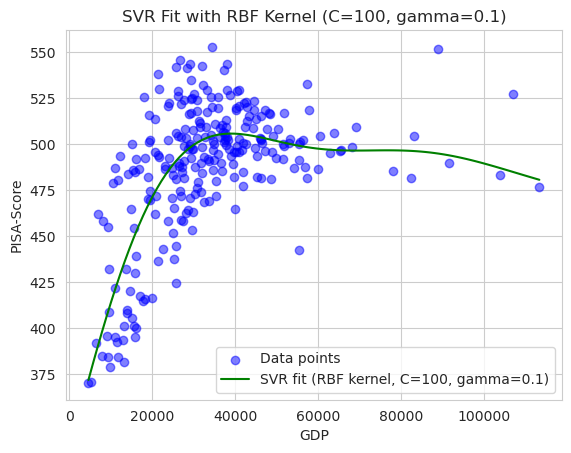

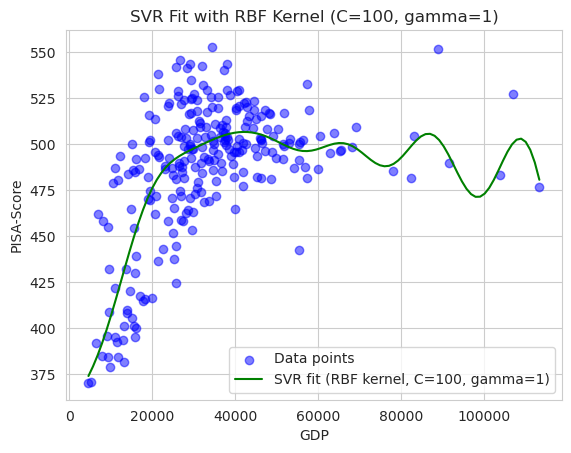

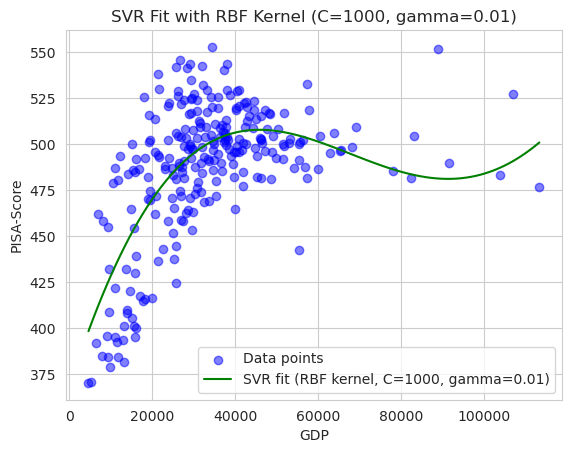

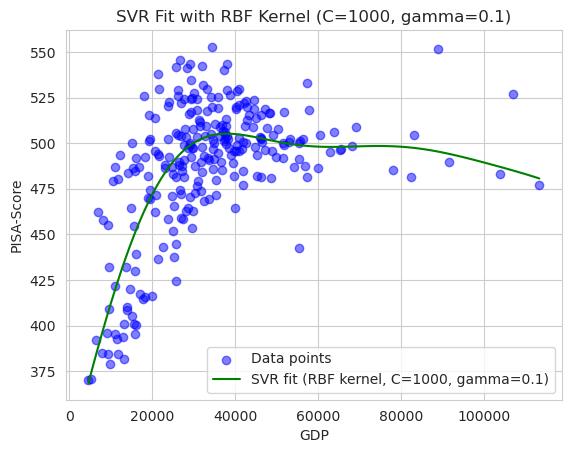

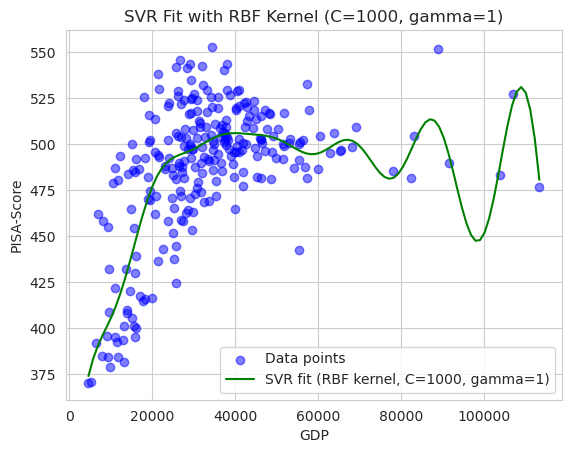

Best parameters: C=1000, gamma=1
Lowest MSE: 670.3895349643965


In [39]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Define a range of parameters to test
C_values = [1, 10, 100, 1000]
gamma_values = [0.01, 0.1, 1]

# Dictionary to store results
results = {}

# Iterate over different values of C and gamma for RBF kernel
for C in C_values:
    for gamma in gamma_values:
        # Train an SVR model with the specified parameters
        svr_model_rbf = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=0.1)
        svr_model_rbf.fit(X_scaled, y_scaled)
        
        # Predict on the fitted range for plotting
        y_fit_scaled_rbf = svr_model_rbf.predict(X_fit_scaled)
        y_fit_rbf = scaler_y.inverse_transform(y_fit_scaled_rbf.reshape(-1, 1)).flatten()
        
        # Calculate mean squared error on the training data
        y_pred_scaled = svr_model_rbf.predict(X_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        mse = mean_squared_error(y, y_pred)
        
        # Store the MSE
        results[(C, gamma)] = mse
        
        # Plot the fit for each parameter combination
        plt.figure()
        plt.scatter(X, y, color='blue', label='Data points', alpha=0.5)
        plt.plot(X_fit, y_fit_rbf, color='green', label=f'SVR fit (RBF kernel, C={C}, gamma={gamma})')
        plt.xlabel("GDP")
        plt.ylabel("PISA-Score")
        plt.legend()
        plt.title(f"SVR Fit with RBF Kernel (C={C}, gamma={gamma})")
        plt.show()

# Find the parameter combination with the lowest MSE
best_params = min(results, key=results.get)
lowest_mse = results[best_params]

# Display the best parameters and the corresponding MSE
print(f"Best parameters: C={best_params[0]}, gamma={best_params[1]}")
print(f"Lowest MSE: {lowest_mse}")


R2 Score for Linear Regression: 0.209
R2 Score for SVR (RBF kernel): 0.512
R2 Score for Polynomial Regression (degree 3): 0.499


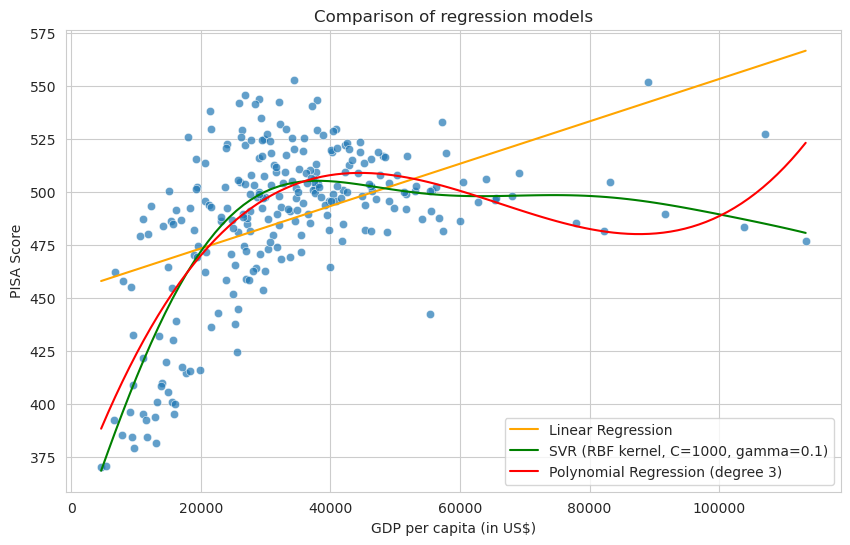

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Extract GDP and PISA-Score columns
X = model_data['GDP'].values.reshape(-1, 1)
y = model_data['PISA-Score'].values

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
y_fit_linear = linear_model.predict(X)

# SVR with RBF kernel
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

svr_best_model = SVR(kernel='rbf', C=1000, gamma=0.1, epsilon=0.1)
svr_best_model.fit(X_scaled, y_scaled)

# Generate predictions for SVR
X_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_fit_scaled = scaler_X.transform(X_fit)
y_fit_scaled_svr = svr_best_model.predict(X_fit_scaled)
y_fit_svr = scaler_y.inverse_transform(y_fit_scaled_svr.reshape(-1, 1)).flatten()

# Polynomial Regression (degree 3)
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Generate predictions for Polynomial Regression
X_fit_poly = poly_features.transform(X_fit)
y_fit_poly = poly_model.predict(X_fit_poly)

# Calculate R2 scores
r2_linear = r2_score(y, y_fit_linear)
y_fit_svr_rescaled = svr_best_model.predict(X_scaled)
y_fit_svr_original = scaler_y.inverse_transform(y_fit_svr_rescaled.reshape(-1, 1)).flatten()
r2_svr = r2_score(y, y_fit_svr_original)
y_fit_poly_res = poly_model.predict(X_poly)
r2_poly = r2_score(y, y_fit_poly_res)

# Print the R2 scores
print(f"R2 Score for Linear Regression: {r2_linear:.3f}")
print(f"R2 Score for SVR (RBF kernel): {r2_svr:.3f}")
print(f"R2 Score for Polynomial Regression (degree {degree}): {r2_poly:.3f}")

# Plotting all models on the same plot
# Plot the scatter plot with annotations
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gdp_score_data, x='GDP', y='PISA-Score', alpha=0.7)
plt.plot(X_fit, linear_model.predict(X_fit), color='orange', label='Linear Regression')
plt.plot(X_fit, y_fit_svr, color='green', label='SVR (RBF kernel, C=1000, gamma=0.1)')
plt.plot(X_fit, y_fit_poly, color='red', label=f'Polynomial Regression (degree {degree})')
plt.xlabel("GDP per capita (in US$)")
plt.ylabel("PISA Score")
plt.legend()
plt.title("Comparison of regression models")
plt.savefig('vis/regression_compare.svg')

plt.show()


# Clustering

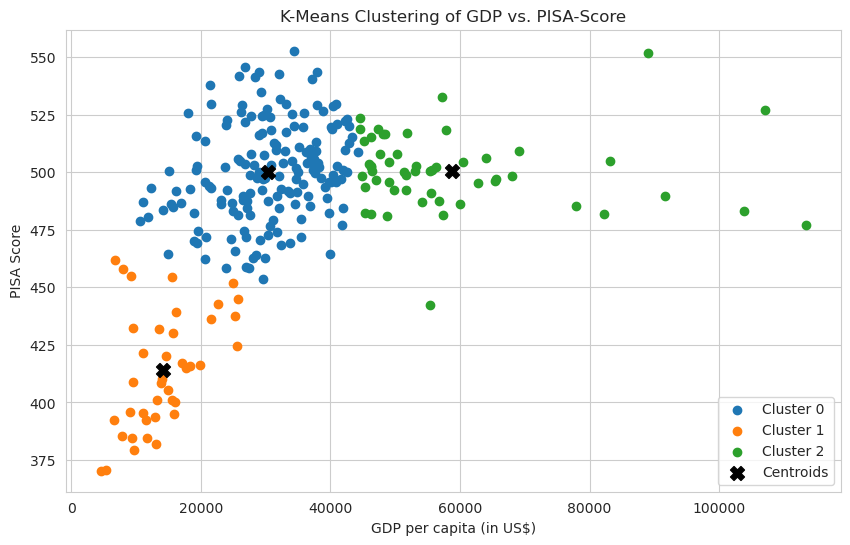

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# Extract GDP and PISA-Score columns for clustering
X = model_data[['GDP', 'PISA-Score']].values


# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform K-Means Clustering
n_clusters = 3  # Define the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)

# Get the cluster labels and add to the dataset
model_data['Cluster'] = kmeans.labels_

# Plot the clusters
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    cluster_points = model_data[model_data['Cluster'] == i]
    plt.scatter(cluster_points['GDP'], cluster_points['PISA-Score'], label=f'Cluster {i}')
    
# Plot the cluster centers (after inverse scaling for interpretability)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=100, label='Centroids')

plt.xlabel("GDP")
plt.ylabel("PISA-Score")
plt.title("K-Means Clustering of GDP vs. PISA-Score")
plt.xlabel("GDP per capita (in US$)")
plt.ylabel("PISA Score")
plt.legend()
plt.savefig('vis/k_means.svg')
plt.show()

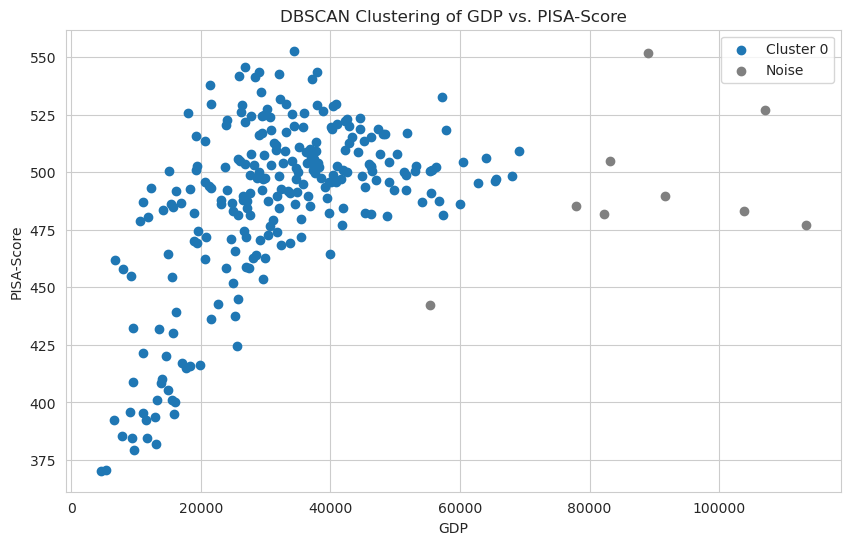

In [42]:
from sklearn.cluster import DBSCAN

# Perform DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # You may adjust eps and min_samples based on data characteristics
dbscan.fit(X_scaled)

# Add DBSCAN cluster labels to the dataset
model_data['DBSCAN_Cluster'] = dbscan.labels_

# Plot the clusters generated by DBSCAN
plt.figure(figsize=(10, 6))
unique_labels = set(dbscan.labels_)
for label in unique_labels:
    cluster_points = model_data[model_data['DBSCAN_Cluster'] == label]
    if label == -1:
        # Noise points are labeled as -1 in DBSCAN
        plt.scatter(cluster_points['GDP'], cluster_points['PISA-Score'], color='grey', label='Noise')
    else:
        plt.scatter(cluster_points['GDP'], cluster_points['PISA-Score'], label=f'Cluster {label}')
        
plt.xlabel("GDP")
plt.ylabel("PISA-Score")
plt.legend()
plt.title("DBSCAN Clustering of GDP vs. PISA-Score")
plt.show()
